In [2]:
import pandas as pd
import numpy as np
import os
import glob

print("Attack-type dataset preparation started!")

processed_path = "../data/CICIDS2017/processed"

processed_files = glob.glob(
    os.path.join(processed_path, "*.csv")
)

print("Files found:", len(processed_files))

for file in processed_files:
    print(os.path.basename(file))

Attack-type dataset preparation started!
Files found: 8
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


In [3]:
# Get attack-type counts without loading all 79 features into memory

from collections import Counter

label_counter = Counter()

for file in processed_files:
    print("Reading labels from:", os.path.basename(file))

    labels = pd.read_csv(
        file,
        usecols=["Label"]
    )

    labels["Label"] = labels["Label"].astype(str).str.strip()

    label_counter.update(labels["Label"].tolist())

print("\n" + "=" * 60)
print("ALL ATTACK TYPES")
print("=" * 60)

label_counts = pd.Series(
    label_counter
).sort_values(ascending=False)

print(label_counts.to_string())

print("\nTotal records:", label_counts.sum())

Reading labels from: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Reading labels from: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Reading labels from: Friday-WorkingHours-Morning.pcap_ISCX.csv
Reading labels from: Monday-WorkingHours.pcap_ISCX.csv
Reading labels from: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Reading labels from: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Reading labels from: Tuesday-WorkingHours.pcap_ISCX.csv
Reading labels from: Wednesday-workingHours.pcap_ISCX.csv

ALL ATTACK TYPES
BENIGN                        2146899
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS               

In [4]:
# Create a balanced multiclass dataset
# without loading the entire CICIDS2017 dataset into memory

MAX_BENIGN = 25000
MAX_PER_ATTACK = 10000

balanced_samples = []

for file in processed_files:

    print("\nProcessing:", os.path.basename(file))

    # Read only required columns + features
    data = pd.read_csv(file)

    data.columns = data.columns.str.strip()

    # Separate benign traffic
    benign = data[data["Label"] == "BENIGN"]

    # Sample benign traffic
    if len(benign) > 0:
        benign_sample = benign.sample(
            n=min(MAX_BENIGN, len(benign)),
            random_state=42
        )

        balanced_samples.append(benign_sample)

        print("BENIGN selected:", len(benign_sample))

    # Process each attack type separately
    attack_labels = data.loc[
        data["Label"] != "BENIGN",
        "Label"
    ].unique()

    for attack_label in attack_labels:

        attack_data = data[
            data["Label"] == attack_label
        ]

        attack_sample = attack_data.sample(
            n=min(MAX_PER_ATTACK, len(attack_data)),
            random_state=42
        )

        balanced_samples.append(attack_sample)

        print(
            attack_label,
            "selected:",
            len(attack_sample)
        )

print("\nCombining selected samples...")

multiclass_data = pd.concat(
    balanced_samples,
    ignore_index=True
)

print("\nFinal multiclass dataset shape:")
print(multiclass_data.shape)

print("\nClass distribution:")
print(
    multiclass_data["Label"]
    .value_counts()
)


Processing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
BENIGN selected: 25000
DDoS selected: 10000

Processing: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
BENIGN selected: 25000
PortScan selected: 10000

Processing: Friday-WorkingHours-Morning.pcap_ISCX.csv
BENIGN selected: 25000
Bot selected: 1948

Processing: Monday-WorkingHours.pcap_ISCX.csv
BENIGN selected: 25000

Processing: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
BENIGN selected: 25000
Infiltration selected: 36

Processing: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
BENIGN selected: 25000
Web Attack � Brute Force selected: 1470
Web Attack � XSS selected: 652
Web Attack � Sql Injection selected: 21

Processing: Tuesday-WorkingHours.pcap_ISCX.csv
BENIGN selected: 25000
FTP-Patator selected: 5931
SSH-Patator selected: 3219

Processing: Wednesday-workingHours.pcap_ISCX.csv
BENIGN selected: 25000
DoS slowloris selected: 5385
DoS Slowhttptest selected: 5228
DoS Hulk selected: 10000
DoS G

In [2]:
import pandas as pd
import numpy as np
import os
import glob

processed_path = "../data/CICIDS2017/processed"

processed_files = glob.glob(
    os.path.join(processed_path, "*.csv")
)

print("Files found:", len(processed_files))
for file in processed_files:
    print(os.path.basename(file))

Files found: 8
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


In [4]:
# Memory-safe multiclass dataset creation

MAX_BENIGN = 25000
MAX_PER_ATTACK = 10000
CHUNK_SIZE = 50000

# CICIDS2017 attack labels
ATTACK_LABELS = [
    "DDoS",
    "PortScan",
    "Bot",
    "Infiltration",
    "Web Attack � Brute Force",
    "Web Attack � XSS",
    "Web Attack � Sql Injection",
    "FTP-Patator",
    "SSH-Patator",
    "DoS Hulk",
    "DoS GoldenEye",
    "DoS slowloris",
    "DoS Slowhttptest",
    "Heartbleed"
]

sample_limits = {
    "BENIGN": MAX_BENIGN
}

for label in ATTACK_LABELS:
    sample_limits[label] = MAX_PER_ATTACK

selected_samples = {
    label: []
    for label in sample_limits
}

selected_counts = {
    label: 0
    for label in sample_limits
}

print("Starting memory-safe sampling...")
print("Maximum samples requested:", sum(sample_limits.values()))

for file in processed_files:

    print("\nProcessing:", os.path.basename(file))

    for chunk in pd.read_csv(
        file,
        chunksize=CHUNK_SIZE
    ):

        chunk.columns = chunk.columns.str.strip()

        for label, limit in sample_limits.items():

            remaining = limit - selected_counts[label]

            if remaining <= 0:
                continue

            class_rows = chunk[
                chunk["Label"] == label
            ]

            if len(class_rows) == 0:
                continue

            n = min(
                remaining,
                len(class_rows)
            )

            sample = class_rows.sample(
                n=n,
                random_state=42
            )

            selected_samples[label].append(sample)
            selected_counts[label] += n

    print(
        "Selected so far:",
        sum(selected_counts.values())
    )

print("\nCombining samples...")

multiclass_data = pd.concat(
    [
        pd.concat(samples, ignore_index=True)
        for samples in selected_samples.values()
        if samples
    ],
    ignore_index=True
)

print("\n" + "=" * 60)
print("MULTICLASS DATASET CREATED")
print("=" * 60)

print("Shape:", multiclass_data.shape)

print("\nClass distribution:")
print(multiclass_data["Label"].value_counts())

Starting memory-safe sampling...
Maximum samples requested: 165000

Processing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Selected so far: 35000

Processing: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Selected so far: 45000

Processing: Friday-WorkingHours-Morning.pcap_ISCX.csv
Selected so far: 46948

Processing: Monday-WorkingHours.pcap_ISCX.csv
Selected so far: 46948

Processing: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Selected so far: 46984

Processing: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Selected so far: 49127

Processing: Tuesday-WorkingHours.pcap_ISCX.csv
Selected so far: 58277

Processing: Wednesday-workingHours.pcap_ISCX.csv
Selected so far: 88901

Combining samples...

MULTICLASS DATASET CREATED
Shape: (88901, 79)

Class distribution:
Label
BENIGN                        25000
DDoS                          10000
PortScan                      10000
DoS GoldenEye                 10000
DoS Hulk                      10000
FTP-

In [5]:
print("Dataset shape:", multiclass_data.shape)

print("\nClass distribution:")
print(multiclass_data["Label"].value_counts().to_string())

print("\nTotal samples:", len(multiclass_data))

Dataset shape: (88901, 79)

Class distribution:
Label
BENIGN                        25000
DDoS                          10000
PortScan                      10000
DoS GoldenEye                 10000
DoS Hulk                      10000
FTP-Patator                    5931
DoS slowloris                  5385
DoS Slowhttptest               5228
SSH-Patator                    3219
Bot                            1948
Web Attack � Brute Force       1470
Web Attack � XSS                652
Infiltration                     36
Web Attack � Sql Injection       21
Heartbleed                       11

Total samples: 88901


In [6]:
# Clean multiclass dataset

print("Starting multiclass dataset cleaning...")

# Clean column names
multiclass_data.columns = multiclass_data.columns.str.strip()

# Remove infinite values
multiclass_data = multiclass_data.replace(
    [np.inf, -np.inf],
    np.nan
)

# Check missing values
missing_before = multiclass_data.isna().sum().sum()

print("Missing/invalid values before cleaning:", missing_before)

# Drop rows containing missing values
multiclass_data = multiclass_data.dropna()

# Remove duplicate rows
duplicates_before = multiclass_data.duplicated().sum()

print("Duplicate rows before removal:", duplicates_before)

multiclass_data = multiclass_data.drop_duplicates()

print("\n" + "=" * 60)
print("CLEANING COMPLETED")
print("=" * 60)

print("Final shape:", multiclass_data.shape)

print("\nMissing values:", multiclass_data.isna().sum().sum())

print("Duplicate rows:", multiclass_data.duplicated().sum())

print("\nClass distribution after cleaning:")
print(
    multiclass_data["Label"]
    .value_counts()
    .to_string()
)

Starting multiclass dataset cleaning...
Missing/invalid values before cleaning: 0
Duplicate rows before removal: 0

CLEANING COMPLETED
Final shape: (88901, 79)

Missing values: 0
Duplicate rows: 0

Class distribution after cleaning:
Label
BENIGN                        25000
DDoS                          10000
PortScan                      10000
DoS GoldenEye                 10000
DoS Hulk                      10000
FTP-Patator                    5931
DoS slowloris                  5385
DoS Slowhttptest               5228
SSH-Patator                    3219
Bot                            1948
Web Attack � Brute Force       1470
Web Attack � XSS                652
Infiltration                     36
Web Attack � Sql Injection       21
Heartbleed                       11


In [7]:
# Prepare features (X) and target (y)

print("Preparing features and target...")

# Columns that should not be used as ML features
columns_to_drop = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp",
    "Label"
]

# Create feature matrix
X_multiclass = multiclass_data.drop(
    columns=columns_to_drop,
    errors="ignore"
)

# Create target variable
y_multiclass = multiclass_data["Label"].copy()

print("=" * 60)
print("MULTICLASS ML DATA PREPARED")
print("=" * 60)

print("X shape:", X_multiclass.shape)
print("y shape:", y_multiclass.shape)

print("\nTarget classes:")
print(y_multiclass.value_counts().to_string())

print("\nNon-numeric columns in X:")
print(
    X_multiclass.select_dtypes(
        exclude=np.number
    ).columns.tolist()
)

Preparing features and target...
MULTICLASS ML DATA PREPARED
X shape: (88901, 78)
y shape: (88901,)

Target classes:
Label
BENIGN                        25000
DDoS                          10000
PortScan                      10000
DoS GoldenEye                 10000
DoS Hulk                      10000
FTP-Patator                    5931
DoS slowloris                  5385
DoS Slowhttptest               5228
SSH-Patator                    3219
Bot                            1948
Web Attack � Brute Force       1470
Web Attack � XSS                652
Infiltration                     36
Web Attack � Sql Injection       21
Heartbleed                       11

Non-numeric columns in X:
[]


In [8]:
print("Number of features:", X_multiclass.shape[1])

print("\nFeature columns:")
for i, column in enumerate(X_multiclass.columns, start=1):
    print(i, column)

Number of features: 78

Feature columns:
1 Destination Port
2 Flow Duration
3 Total Fwd Packets
4 Total Backward Packets
5 Total Length of Fwd Packets
6 Total Length of Bwd Packets
7 Fwd Packet Length Max
8 Fwd Packet Length Min
9 Fwd Packet Length Mean
10 Fwd Packet Length Std
11 Bwd Packet Length Max
12 Bwd Packet Length Min
13 Bwd Packet Length Mean
14 Bwd Packet Length Std
15 Flow Bytes/s
16 Flow Packets/s
17 Flow IAT Mean
18 Flow IAT Std
19 Flow IAT Max
20 Flow IAT Min
21 Fwd IAT Total
22 Fwd IAT Mean
23 Fwd IAT Std
24 Fwd IAT Max
25 Fwd IAT Min
26 Bwd IAT Total
27 Bwd IAT Mean
28 Bwd IAT Std
29 Bwd IAT Max
30 Bwd IAT Min
31 Fwd PSH Flags
32 Bwd PSH Flags
33 Fwd URG Flags
34 Bwd URG Flags
35 Fwd Header Length
36 Bwd Header Length
37 Fwd Packets/s
38 Bwd Packets/s
39 Min Packet Length
40 Max Packet Length
41 Packet Length Mean
42 Packet Length Std
43 Packet Length Variance
44 FIN Flag Count
45 SYN Flag Count
46 RST Flag Count
47 PSH Flag Count
48 ACK Flag Count
49 URG Flag Count
50

In [9]:
from sklearn.preprocessing import LabelEncoder

# Encode attack-type labels
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y_multiclass)

print("=" * 60)
print("ATTACK TYPE LABEL ENCODING")
print("=" * 60)

print("Number of classes:", len(label_encoder.classes_))

print("\nClass mapping:")
for number, label in enumerate(label_encoder.classes_):
    print(number, "->", label)

print("\nEncoded target shape:", y_encoded.shape)

ATTACK TYPE LABEL ENCODING
Number of classes: 15

Class mapping:
0 -> BENIGN
1 -> Bot
2 -> DDoS
3 -> DoS GoldenEye
4 -> DoS Hulk
5 -> DoS Slowhttptest
6 -> DoS slowloris
7 -> FTP-Patator
8 -> Heartbleed
9 -> Infiltration
10 -> PortScan
11 -> SSH-Patator
12 -> Web Attack � Brute Force
13 -> Web Attack � Sql Injection
14 -> Web Attack � XSS

Encoded target shape: (88901,)


In [10]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_multiclass,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

print("\nTraining class distribution:")
print(
    pd.Series(y_train)
    .value_counts()
    .sort_index()
)

print("\nTesting class distribution:")
print(
    pd.Series(y_test)
    .value_counts()
    .sort_index()
)

TRAIN / TEST SPLIT
Training features: (71120, 78)
Testing features: (17781, 78)
Training labels: (71120,)
Testing labels: (17781,)

Training class distribution:
0     20000
1      1558
2      8000
3      8000
4      8000
5      4182
6      4308
7      4745
8         9
9        29
10     8000
11     2575
12     1176
13       17
14      521
Name: count, dtype: int64

Testing class distribution:
0     5000
1      390
2     2000
3     2000
4     2000
5     1046
6     1077
7     1186
8        2
9        7
10    2000
11     644
12     294
13       4
14     131
Name: count, dtype: int64


In [11]:
from sklearn.ensemble import RandomForestClassifier
import time
import joblib
import os

print("=" * 60)
print("TRAINING ATTACK-TYPE CLASSIFICATION MODEL")
print("=" * 60)

start_time = time.time()

attack_type_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

attack_type_model.fit(
    X_train,
    y_train
)

training_time = time.time() - start_time

print("\nTraining completed!")
print(f"Training time: {training_time:.2f} seconds")

print("\nModel:")
print(attack_type_model)

TRAINING ATTACK-TYPE CLASSIFICATION MODEL

Training completed!
Training time: 18.55 seconds

Model:
RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("=" * 60)
print("ATTACK-TYPE MODEL EVALUATION")
print("=" * 60)

# Make predictions on unseen test data
y_pred = attack_type_model.predict(X_test)

# Calculate overall metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

ATTACK-TYPE MODEL EVALUATION

Accuracy : 0.9876
Precision: 0.9869
Recall   : 0.9876
F1-Score : 0.9871

CLASSIFICATION REPORT
                            precision    recall  f1-score   support

                    BENIGN       0.99      1.00      0.99      5000
                       Bot       0.96      0.96      0.96       390
                      DDoS       1.00      1.00      1.00      2000
             DoS GoldenEye       1.00      1.00      1.00      2000
                  DoS Hulk       1.00      1.00      1.00      2000
          DoS Slowhttptest       1.00      0.99      0.99      1046
             DoS slowloris       0.99      1.00      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.57      0.73         7
                  PortScan       1.00      1.00      1.00      2000
               SSH-Patator       1.00      1.00      1.00 

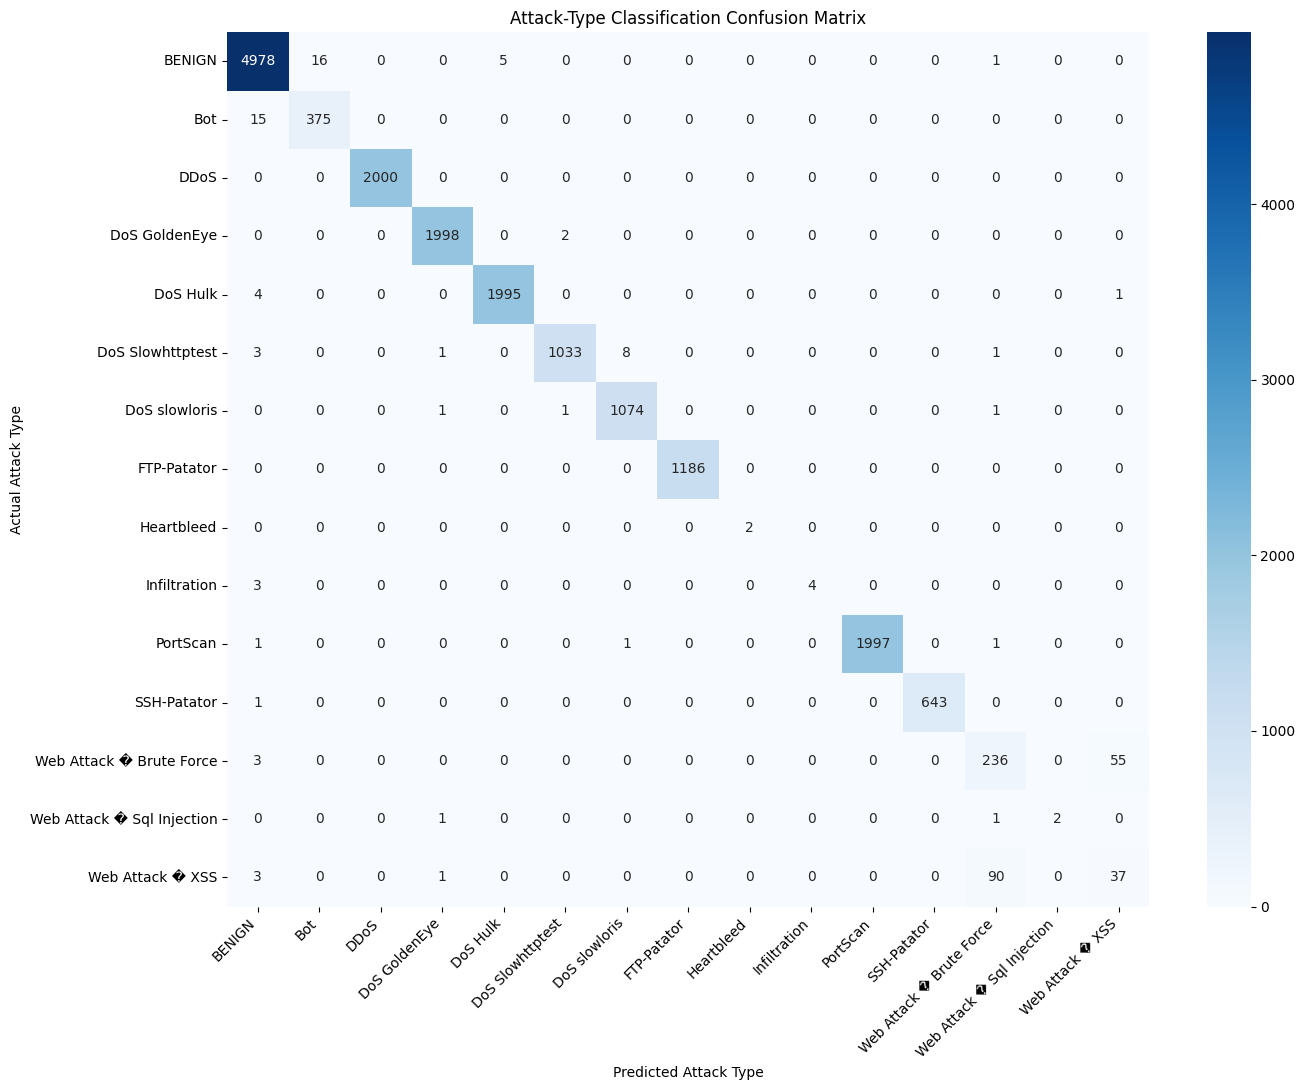

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(len(label_encoder.classes_))
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Attack-Type Classification Confusion Matrix")
plt.xlabel("Predicted Attack Type")
plt.ylabel("Actual Attack Type")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

TOP 20 IMPORTANT FEATURES
                    Feature  Importance
           Destination Port    0.066727
    Init_Win_bytes_backward    0.055284
       min_seg_size_forward    0.026602
      Fwd Packet Length Max    0.026312
             Flow Packets/s    0.025687
              Bwd Packets/s    0.025102
       Avg Bwd Segment Size    0.024965
        Average Packet Size    0.024489
Total Length of Bwd Packets    0.024286
        Fwd Header Length.1    0.022461
          Bwd Header Length    0.021908
               Flow IAT Max    0.021722
         Packet Length Mean    0.021398
              Flow IAT Mean    0.020898
          Max Packet Length    0.020645
              Flow Duration    0.020496
          Subflow Fwd Bytes    0.019571
      Bwd Packet Length Max    0.019459
                Fwd IAT Max    0.019164
          Fwd Header Length    0.018437


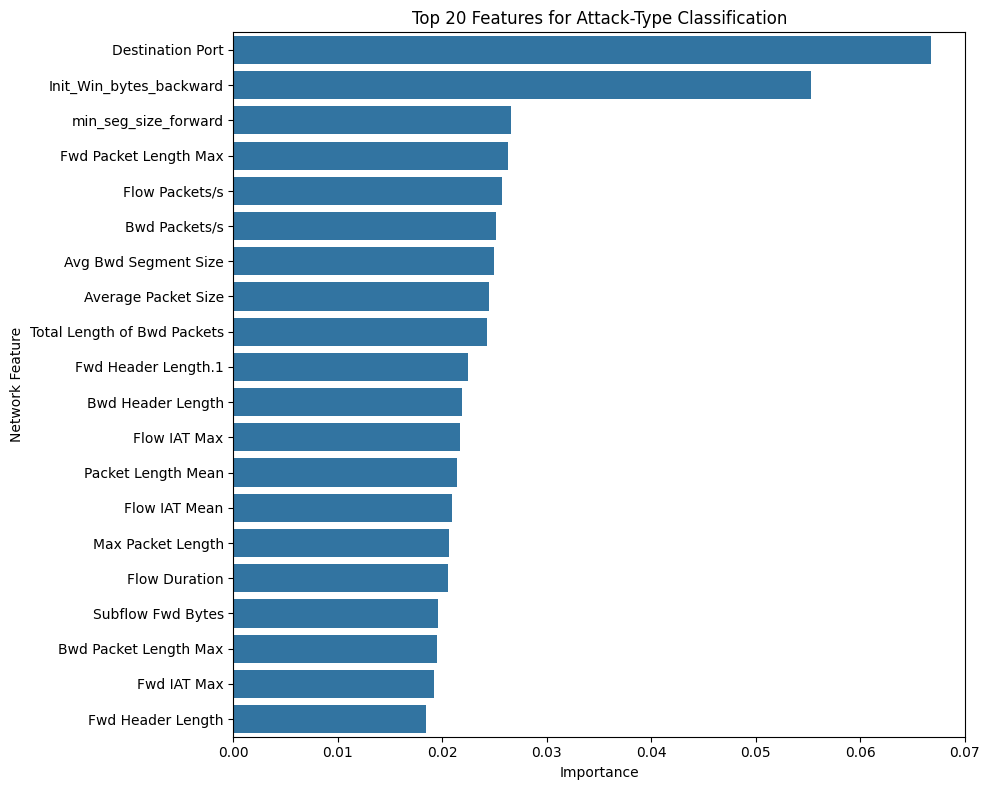

In [14]:
# Feature importance analysis

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": attack_type_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    feature_importance.head(20).to_string(index=False)
)

# Plot top 20 features
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Features for Attack-Type Classification")
plt.xlabel("Importance")
plt.ylabel("Network Feature")
plt.tight_layout()
plt.show()

In [15]:
# Save attack-type classification model and label encoder

MODEL_DIR = "../models"

os.makedirs(MODEL_DIR, exist_ok=True)

# Save Random Forest model
attack_type_model_path = os.path.join(
    MODEL_DIR,
    "attack_type_random_forest.joblib"
)

joblib.dump(
    attack_type_model,
    attack_type_model_path
)

# Save label encoder
label_encoder_path = os.path.join(
    MODEL_DIR,
    "attack_type_label_encoder.joblib"
)

joblib.dump(
    label_encoder,
    label_encoder_path
)

print("=" * 60)
print("MODEL SAVING COMPLETED")
print("=" * 60)

print("\nAttack-type model saved to:")
print(attack_type_model_path)

print("\nLabel encoder saved to:")
print(label_encoder_path)

print("\nModel files created successfully!")

MODEL SAVING COMPLETED

Attack-type model saved to:
../models\attack_type_random_forest.joblib

Label encoder saved to:
../models\attack_type_label_encoder.joblib

Model files created successfully!


In [16]:
# Verify saved attack-type model

saved_model = joblib.load(
    "../models/attack_type_random_forest.joblib"
)

saved_encoder = joblib.load(
    "../models/attack_type_label_encoder.joblib"
)

# Predict using the test data
sample_predictions = saved_model.predict(
    X_test.iloc[:10]
)

predicted_attack_types = saved_encoder.inverse_transform(
    sample_predictions
)

print("=" * 60)
print("SAVED MODEL VERIFICATION")
print("=" * 60)

for i, attack_type in enumerate(predicted_attack_types, start=1):
    print(f"Sample {i}: {attack_type}")

print("\nSaved model loaded successfully!")
print("Saved label encoder loaded successfully!")

SAVED MODEL VERIFICATION
Sample 1: DoS slowloris
Sample 2: Web Attack � Brute Force
Sample 3: PortScan
Sample 4: DoS GoldenEye
Sample 5: DoS Hulk
Sample 6: BENIGN
Sample 7: BENIGN
Sample 8: PortScan
Sample 9: DDoS
Sample 10: PortScan

Saved model loaded successfully!
Saved label encoder loaded successfully!


In [20]:
# ============================================================
# NOTEBOOK 13
# CICIDS2017 ATTACK-TYPE CLASSIFICATION
# ============================================================

import os
import glob
import warnings
import time

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

warnings.filterwarnings("ignore")


# ============================================================
# 1. FIND PROJECT ROOT
# ============================================================

# Notebook is running from:
# ...\Network-Anomaly-Detection-and-Predictive-Intrusion-Monitoring-Platform\ml\notebooks

NOTEBOOK_DIR = os.getcwd()

# Move from ml/notebooks -> ml -> project root
PROJECT_ROOT = os.path.abspath(
    os.path.join(NOTEBOOK_DIR, "..", "..")
)

DATA_DIR = os.path.join(
    PROJECT_ROOT,
    "ml",
    "data",
    "CICIDS2017",
    "processed"
)

MODEL_DIR = os.path.join(
    PROJECT_ROOT,
    "ml",
    "models"
)

os.makedirs(MODEL_DIR, exist_ok=True)


print("=" * 70)
print("CICIDS2017 ATTACK-TYPE CLASSIFICATION")
print("=" * 70)

print("\nNotebook directory:")
print(NOTEBOOK_DIR)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nProcessed data directory:")
print(DATA_DIR)

print("\nModel directory:")
print(MODEL_DIR)


# ============================================================
# 2. FIND PROCESSED CICIDS2017 FILES
# ============================================================

csv_files = sorted(
    glob.glob(os.path.join(DATA_DIR, "*.csv"))
)

print("\nNumber of processed CICIDS2017 files:", len(csv_files))

if len(csv_files) == 0:
    raise FileNotFoundError(
        f"\nNo processed CICIDS2017 CSV files found in:\n{DATA_DIR}"
    )

print("\nFiles found:")

for file in csv_files:
    print(" -", os.path.basename(file))


# ============================================================
# 3. LABEL CLEANING FUNCTION
# ============================================================

def clean_attack_label(label):
    """
    Standardize CICIDS2017 attack labels.

    The original CICIDS2017 CSV files contain corrupted
    characters in some Web Attack labels. This function
    converts them into clean readable labels.
    """

    if pd.isna(label):
        return "BENIGN"

    label = str(label).strip()

    # Normalize corrupted Web Attack labels
    label = label.replace(
        "Web Attack � Brute Force",
        "Web Attack - Brute Force"
    )

    label = label.replace(
        "Web Attack � Sql Injection",
        "Web Attack - Sql Injection"
    )

    label = label.replace(
        "Web Attack � XSS",
        "Web Attack - XSS"
    )

    # Handle possible alternative dash/encoding forms
    label = label.replace(
        "Web Attack – Brute Force",
        "Web Attack - Brute Force"
    )

    label = label.replace(
        "Web Attack – Sql Injection",
        "Web Attack - Sql Injection"
    )

    label = label.replace(
        "Web Attack – XSS",
        "Web Attack - XSS"
    )

    return label


# ============================================================
# 4. PARAMETERS
# ============================================================

MAX_BENIGN = 25000
MAX_PER_ATTACK = 10000

RANDOM_STATE = 42

CHUNK_SIZE = 50000


# ============================================================
# 5. COLLECT DATA
# ============================================================

print("\n" + "=" * 70)
print("LOADING AND SAMPLING DATA")
print("=" * 70)

all_data = []

for file in csv_files:

    file_name = os.path.basename(file)

    print(f"\nProcessing: {file_name}")

    chunks = []

    for chunk in pd.read_csv(
        file,
        chunksize=CHUNK_SIZE,
        low_memory=False
    ):

        # Remove spaces from column names
        chunk.columns = chunk.columns.str.strip()

        # Clean labels
        if "Label" not in chunk.columns:
            print("  WARNING: Label column not found.")
            continue

        chunk["Label"] = chunk["Label"].apply(
            clean_attack_label
        )

        # Replace infinity values
        chunk.replace(
            [np.inf, -np.inf],
            np.nan,
            inplace=True
        )

        # Remove rows containing missing values
        chunk.dropna(inplace=True)

        # Remove exact duplicate rows
        chunk.drop_duplicates(inplace=True)

        chunks.append(chunk)

    if not chunks:
        print("  No usable data found.")
        continue

    file_data = pd.concat(
        chunks,
        ignore_index=True
    )

    print(
        "  Rows after cleaning:",
        len(file_data)
    )

    all_data.append(file_data)


# ============================================================
# 6. COMBINE ALL DATA
# ============================================================

if not all_data:
    raise ValueError(
        "No usable CICIDS2017 data was loaded."
    )

data = pd.concat(
    all_data,
    ignore_index=True
)

print("\nTotal cleaned rows:", len(data))


# ============================================================
# 7. DISPLAY ATTACK LABELS
# ============================================================

print("\nAttack labels found:")

label_counts = data["Label"].value_counts()

print(label_counts)


# ============================================================
# 8. BALANCED CLASS SAMPLING
# ============================================================

print("\n" + "=" * 70)
print("CREATING BALANCED ATTACK-TYPE DATASET")
print("=" * 70)

sampled_parts = []

for label, group in data.groupby("Label"):

    if label == "BENIGN":

        sample_size = min(
            MAX_BENIGN,
            len(group)
        )

    else:

        sample_size = min(
            MAX_PER_ATTACK,
            len(group)
        )

    sampled_group = group.sample(
        n=sample_size,
        random_state=RANDOM_STATE
    )

    sampled_parts.append(sampled_group)

    print(
        f"{label:<35} -> {sample_size:,} rows"
    )


# Combine sampled classes
data = pd.concat(
    sampled_parts,
    ignore_index=True
)

# Shuffle
data = data.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)


print("\nFinal dataset shape:", data.shape)


# ============================================================
# 9. FINAL LABEL CHECK
# ============================================================

print("\nFinal class distribution:")

print(
    data["Label"].value_counts()
)


# ============================================================
# 10. REMOVE NETWORK IDENTIFIERS
# ============================================================

columns_to_drop = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp",
    "Label"
]

existing_columns_to_drop = [
    column
    for column in columns_to_drop
    if column in data.columns
]

X = data.drop(
    columns=existing_columns_to_drop
)

y = data["Label"]


# ============================================================
# 11. ENSURE NUMERIC FEATURES
# ============================================================

print("\nFeature columns before numeric conversion:")
print("Number of features:", X.shape[1])

# Convert all features to numeric
X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

# Replace infinity
X.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

# Fill remaining missing values
X.fillna(
    0,
    inplace=True
)


# ============================================================
# 12. VERIFY DATA
# ============================================================

print("\nFeature matrix shape:", X.shape)

print(
    "Missing values:",
    X.isna().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(X.to_numpy()).sum()
)


# ============================================================
# 13. LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)


print("\n" + "=" * 70)
print("LABEL ENCODING")
print("=" * 70)

for number, label in enumerate(
    label_encoder.classes_
):
    print(
        f"{number:2d} -> {label}"
    )


print(
    "\nNumber of classes:",
    len(label_encoder.classes_)
)


# ============================================================
# 14. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ============================================================
# 15. TRAIN RANDOM FOREST
# ============================================================

print("\n" + "=" * 70)
print("TRAINING RANDOM FOREST")
print("=" * 70)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

start_time = time.time()

model.fit(
    X_train,
    y_train
)

training_time = time.time() - start_time

print(
    f"\nTraining completed in {training_time:.2f} seconds."
)


# ============================================================
# 16. PREDICTIONS
# ============================================================

print("\nGenerating predictions...")

y_pred = model.predict(X_test)


# ============================================================
# 17. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1 Score : {f1:.4f}"
)


# ============================================================
# 18. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


# ============================================================
# 19. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)


# ============================================================
# 20. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n" + "=" * 70)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 70)

print(
    feature_importance.head(20).to_string(
        index=False
    )
)


# ============================================================
# 21. SAVE RANDOM FOREST MODEL
# ============================================================

model_path = os.path.join(
    MODEL_DIR,
    "attack_type_random_forest.joblib"
)

joblib.dump(
    model,
    model_path
)

print(
    "\nModel saved to:"
)

print(model_path)


# ============================================================
# 22. SAVE LABEL ENCODER
# ============================================================

encoder_path = os.path.join(
    MODEL_DIR,
    "attack_type_label_encoder.joblib"
)

joblib.dump(
    label_encoder,
    encoder_path
)

print(
    "\nLabel encoder saved to:"
)

print(encoder_path)


# ============================================================
# 23. VERIFY SAVED MODEL
# ============================================================

print("\n" + "=" * 70)
print("VERIFYING SAVED MODEL")
print("=" * 70)

loaded_model = joblib.load(
    model_path
)

loaded_encoder = joblib.load(
    encoder_path
)

print(
    "Model type:",
    type(loaded_model).__name__
)

print(
    "Number of trees:",
    loaded_model.n_estimators
)

print(
    "Number of features:",
    loaded_model.n_features_in_
)

print(
    "Number of classes:",
    len(loaded_encoder.classes_)
)

print(
    "Classes:"
)

print(
    loaded_encoder.classes_
)


# ============================================================
# 24. TEST ONE SAMPLE
# ============================================================

print("\n" + "=" * 70)
print("SAMPLE PREDICTION TEST")
print("=" * 70)

sample = X_test.iloc[[0]]

sample_prediction = loaded_model.predict(
    sample
)

sample_label = loaded_encoder.inverse_transform(
    sample_prediction
)[0]

print(
    "Predicted attack type:",
    sample_label
)


# ============================================================
# 25. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("ATTACK-TYPE CLASSIFICATION COMPLETED")
print("=" * 70)

print(
    f"Final dataset size : {data.shape}"
)

print(
    f"Number of features : {X.shape[1]}"
)

print(
    f"Number of classes  : {len(label_encoder.classes_)}"
)

print(
    f"Accuracy           : {accuracy:.4f}"
)

print(
    f"Precision          : {precision:.4f}"
)

print(
    f"Recall             : {recall:.4f}"
)

print(
    f"F1 Score           : {f1:.4f}"
)

print(
    "\nSaved files:"
)

print(
    "- attack_type_random_forest.joblib"
)

print(
    "- attack_type_label_encoder.joblib"
)

print("\n" + "=" * 70)

CICIDS2017 ATTACK-TYPE CLASSIFICATION

Notebook directory:
c:\Users\vsiva\AI-Network-Security-Project\Network-Anomaly-Detection-and-Predictive-Intrusion-Monitoring-Platform\ml\notebooks

Project root:
c:\Users\vsiva\AI-Network-Security-Project\Network-Anomaly-Detection-and-Predictive-Intrusion-Monitoring-Platform

Processed data directory:
c:\Users\vsiva\AI-Network-Security-Project\Network-Anomaly-Detection-and-Predictive-Intrusion-Monitoring-Platform\ml\data\CICIDS2017\processed

Model directory:
c:\Users\vsiva\AI-Network-Security-Project\Network-Anomaly-Detection-and-Predictive-Intrusion-Monitoring-Platform\ml\models

Number of processed CICIDS2017 files: 8

Files found:
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tues

In [19]:
import os
print(os.getcwd())

c:\Users\vsiva\AI-Network-Security-Project\Network-Anomaly-Detection-and-Predictive-Intrusion-Monitoring-Platform\ml\notebooks
